CONTEXTUALIZANDO

Churn é o cancelamento ou abandono de clientes, e prever esse comportamento é essencial porque reter um cliente custa até 5x menos do que adquirir um novo. O impacto no negócio é direto: alta taxa de churn reduz receita recorrente, compromete o LTV (Lifetime Value) e sinaliza falhas na experiência do cliente. O objetivo do modelo é identificar, com antecedência, quais clientes têm maior probabilidade de churnar, permitindo ações proativas de retenção, como ofertas personalizadas ou contato preventivo. Serão previstos clientes com risco elevado de cancelamento no curto prazo, com base em padrões de comportamento, engajamento e histórico de uso. Assim, a empresa transforma dados em decisões estratégicas antes que a perda aconteça.

## **Entendimento dos dados**



In [ ]:
# Carregando os dados e bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score

from google.colab import files
uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling (12).csv


In [ ]:
df = pd.read_csv('Churn_Modelling.csv')

In [ ]:
# Mostra quantas linhas e colunas a base possui
print(f'Base carregada com {df.shape[0]} linhas e {df.shape[1]} colunas.')

# Listando todas colunas
print('\nNomes das colunas:')
print(df.columns)

# Tipos de dados de cada coluna
print('\nTipos de dados:')
print(df.dtypes)

print('\nMostra o tipo de dado de cada coluna, se exitem valores nulos:')
df.info()

# Verifica valores nulos em cada coluna do DataFrame.
# .isnull() retorna True para células vazias, e .sum() soma quantos existem por coluna.
# Importante para tratar os dados antes de seguir com a analise
print('\nVerifica a existencia de valores nulos:')
df.isnull().sum()

Base carregada com 10000 linhas e 14 colunas.

Nomes das colunas:
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

Tipos de dados:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Mostra o tipo de dado de cada coluna, se exitem valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


### Preparacao dos **dados**
1. remover valores ausentes, se tiver
2. separar variaveis explicativas (X)
3. separar variavel alvo (y)
4. dividir treino e teste


In [ ]:
# Removendo valores ausentes
df.dropna(inplace=True)
df.head()
df.sample(5, random_state=42)
df['Exited'].value_counts(normalize=True)

,proportion
Exited,
0,0.7963
1,0.2037


## **Divisao - Treino / Teste**

In [ ]:
# Removendo colunas desnecessarias e criando X (features) e y (target)
# 'RowNumber', 'CustomerId', e 'Surname' são identificadores ou texto livre e não são úteis como features para o modelo.
# 'Exited' é a variável alvo para previsão de churn.
X = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Exited'])
y = df['Exited'] # 'Exited' é a variável alvo (churn)

# Aplicar One-Hot Encoding para variáveis categóricas restantes em X: 'Geography' e 'Gender'.
X = pd.get_dummies(X, columns=['Geography', 'Gender'], drop_first=True) # drop_first evita multicolinearidade

# Separacao em treino e teste
# Usamos stratify=y porque 'Exited' é uma variável categórica (0 ou 1) e queremos manter as proporções de churn
# nos conjuntos de treino e teste.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=255, stratify=y)

print(f'Dataset --> Tamanho treino: {X_train.shape[0]} | Tamanho teste: {X_test.shape[0]}')

Dataset --> Tamanho treino: 8000 | Tamanho teste: 2000


### **Modelagem**

Treinando e Avaliando: Random Forest...

Relatório de Classificação - Random Forest:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



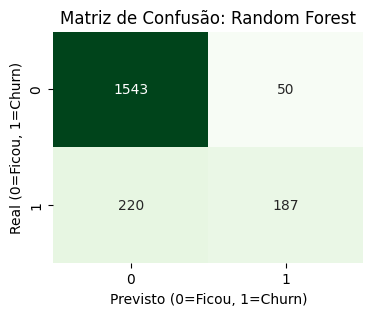

--------------------------------------------------
Treinando e Avaliando: Gradient Boosting...

Relatório de Classificação - Gradient Boosting:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.76      0.47      0.58       407

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



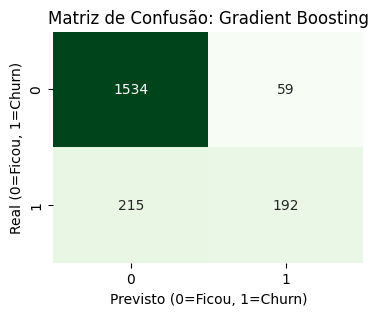

--------------------------------------------------
Treinando e Avaliando: XGBoost...

Relatório de Classificação - XGBoost:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1593
           1       0.69      0.50      0.58       407

    accuracy                           0.85      2000
   macro avg       0.79      0.72      0.74      2000
weighted avg       0.84      0.85      0.84      2000



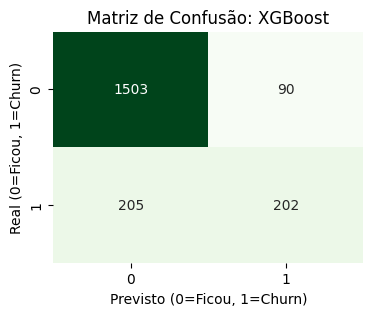

--------------------------------------------------
Treinando e Avaliando: LightGBM...

Relatório de Classificação - LightGBM:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1593
           1       0.75      0.54      0.63       407

    accuracy                           0.87      2000
   macro avg       0.82      0.75      0.77      2000
weighted avg       0.86      0.87      0.86      2000



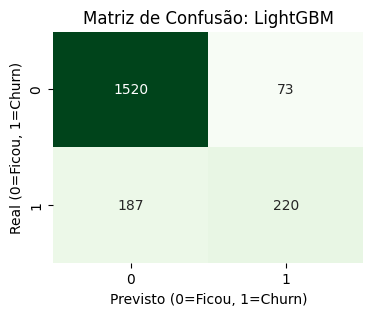

--------------------------------------------------


In [ ]:
# Definição dos Modelos
modelos = {
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1), # Melhor em estabilidade e simplicidade, é o mais dificil de overfitar, otimo para modelos baseline, pois funciona bem mesmo sem nenhum ajuste de hiperparametros
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),    # Constrói árvores sequencialmente para reduzir o erro. É muito potente, mas costuma ser o mais lento para treinar entre os quatro.
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),    # É uma versão otimizada do Gradient Boosting que lida muito bem com dados faltantes e tem controles internos para não decorar o treino.
    "LightGBM": LGBMClassifier(random_state=42, verbosity=-1)            # É o mais rápido de todos. Enquanto os outros crescem as árvores por "nível", ele cresce por "folha", o que o torna extremamente eficiente em datasets com muitas linhas ou colunas.
}                                               # verbosity=-1 limpa avisos extras

# Estruturas para armazenar os resultados
resultados_metricas = []

# Loop de Treinamento e Avaliação
for nome, modelo in modelos.items():
    print(f"Treinando e Avaliando: {nome}...")

# Treino
    modelo.fit(X_train, y_train)

# Predição
    y_pred = modelo.predict(X_test)

# Cálculo das métricas individuais
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

# Armazenando para a tabela comparativa
    resultados_metricas.append({
        'Modelo': nome,
        'Acurácia': acc,
        'Precisão': prec,
        'Recall': rec,
        'F1-Score': f1
    })

# Print do Relatório de Classificação
    print(f"\nRelatório de Classificação - {nome}:")
    print(classification_report(y_test, y_pred))

# Plot da Matriz de Confusão
    plt.figure(figsize=(4, 3))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
    plt.title(f'Matriz de Confusão: {nome}')
    plt.xlabel('Previsto (0=Ficou, 1=Churn)')
    plt.ylabel('Real (0=Ficou, 1=Churn)')
    plt.show()
    print("-" * 50)


### **Avaliação Experimental (Métricas e Interpretação)**

In [ ]:
# Criação e exibição da Tabela Comparativa Final
df_comparativo = pd.DataFrame(resultados_metricas).set_index('Modelo')

print("\n" + "="*30)
print("TABELA COMPARATIVA FINAL")
print("="*30)
# Ordenamos pelo Recall, que é crítico para problemas de Churn
display(df_comparativo.sort_values(by='Recall', ascending=False))


TABELA COMPARATIVA FINAL


,Acurácia,Precisão,Recall,F1-Score
Modelo,,,,
LightGBM,0.8700,0.750853,0.540541,0.628571
XGBoost,0.8525,0.691781,0.496314,0.577969
Gradient Boosting,0.8630,0.764940,0.471744,0.583587
Random Forest,0.8650,0.789030,0.459459,0.580745


## **Eles acertam o Churn?**
Sim, mas com ressalvas. Todos os modelos têm uma Acurácia alta (acima de 85%), o que significa que eles acertam a maioria dos casos gerais. No entanto, o Recall (que mede o acerto específico da "classe churn") está entre 45% e 54%.

Isso significa que, na melhor das hipóteses (LightGBM), o modelo detecta apenas 54 de cada 100 clientes que vão embora. Os outros 46 saem sem o modelo avisar.

# **Conclusao**
O modelo LightGBM foi selecionado como a solução ideal. Ele apresentou o melhor desempenho na métrica Recall, sendo capaz de identificar uma parcela significativamente maior de clientes em risco de evasão do que os modelos concorrentes. Embora a Random Forest tenha tido uma Precisão ligeiramente maior (evitando alarmes falsos), no contexto de Churn, a prioridade é a retenção, tornando o LightGBM a escolha mais estratégica por sua capacidade superior de detecção."